In [153]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df = pd.read_csv('train.csv')

In [155]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [156]:
df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [157]:
df.columns = ['BatteryPower','Blue','ClkSpeed','DualSim','FrontCamMB'
              ,'4G','IntMemory','Depth','Weight','NumOfCores','PrimaryCamMB'
              ,'PxlHeight','PxlWidth','Ram','ScreenHeight','ScreenWidth'
              ,'TalkTime','3G','TouchScreen',
              'Wifi','PriceRange']

In [158]:
df.head()

,BatteryPower,Blue,ClkSpeed,DualSim,FrontCamMB,4G,IntMemory,Depth,Weight,NumOfCores,...,PxlHeight,PxlWidth,Ram,ScreenHeight,ScreenWidth,TalkTime,3G,TouchScreen,Wifi,PriceRange
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [159]:
len(df)

2000

In [160]:
df.shape

(2000, 21)

In [161]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
BatteryPower,2000.0,1238.51850,439.418206,501.0,851.75,1226.0,1615.25,1998.0
Blue,2000.0,0.49500,0.500100,0.0,0.00,0.0,1.00,1.0
ClkSpeed,2000.0,1.52225,0.816004,0.5,0.70,1.5,2.20,3.0
DualSim,2000.0,0.50950,0.500035,0.0,0.00,1.0,1.00,1.0
FrontCamMB,2000.0,4.30950,4.341444,0.0,1.00,3.0,7.00,19.0
4G,2000.0,0.52150,0.499662,0.0,0.00,1.0,1.00,1.0
IntMemory,2000.0,32.04650,18.145715,2.0,16.00,32.0,48.00,64.0
Depth,2000.0,0.50175,0.288416,0.1,0.20,0.5,0.80,1.0
Weight,2000.0,140.24900,35.399655,80.0,109.00,141.0,170.00,200.0
NumOfCores,2000.0,4.52050,2.287837,1.0,3.00,4.0,7.00,8.0


<Axes: >

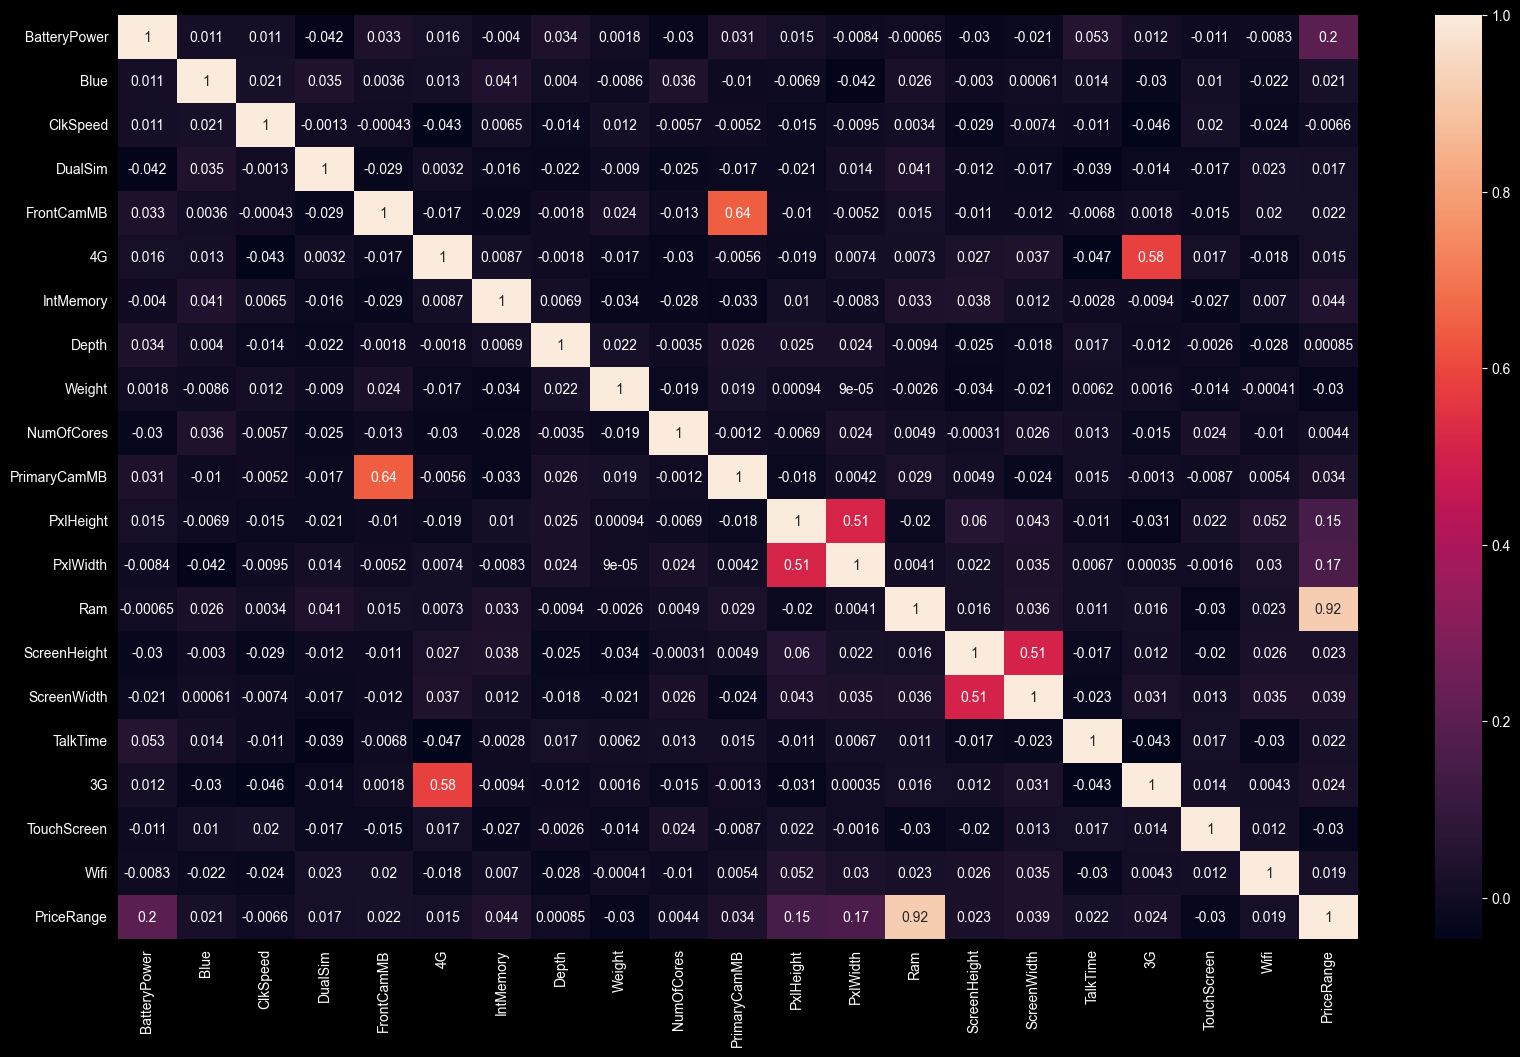

In [162]:
plt.figure(figsize=(20,12))
corr = df.corr()
sns.heatmap(corr,annot=True)

In [163]:
sub_Correlation = ['BatteryPower','IntMemory','Weight','NumOfCores']

<Axes: >

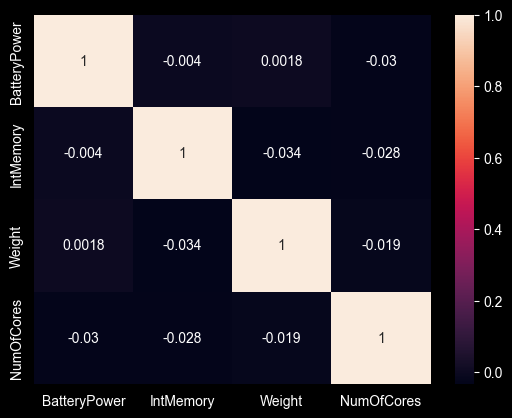

In [164]:
sns.heatmap(df[sub_Correlation].corr(),annot=True)

In [165]:

df['PriceRange'] = (
    df['BatteryPower'] * 0.08
    + df['Ram'] * 25
    + df['IntMemory'] * 3
    + df['PrimaryCamMB'] * 15
    + df['FrontCamMB'] * 8
    + df['4G'] * 120
    + df['Wifi'] * 80
    + df['TouchScreen'] * 50
    - df['Weight'] * 0.5
    + np.random.normal(0, 100, len(df))
)

In [166]:
df['PriceRange'].head(1)

0    63813.944554
Name: PriceRange, dtype: float64

In [167]:
X = df.drop('PriceRange',axis=1)

In [168]:
y = df['PriceRange']

In [169]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [170]:
from sklearn.model_selection import train_test_split

In [171]:
X_train,X_test,y_train,y_test = train_test_split(
    X,y , test_size=0.25 ,random_state=42
)

In [172]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        max_features='sqrt',
        bootstrap=True,
        random_state=42,
        n_jobs=-1
    ))
])

In [173]:
pipe.fit(X_train,y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_estimators,300
,criterion,'squared_error'
,max_depth,20
,min_samples_split,5


In [174]:
y_pred = pipe.predict(X_test)

In [175]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [176]:


print("R2:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2: 0.9453669448525097
MAE: 4882.575351971517
RMSE: 6397.70760782222


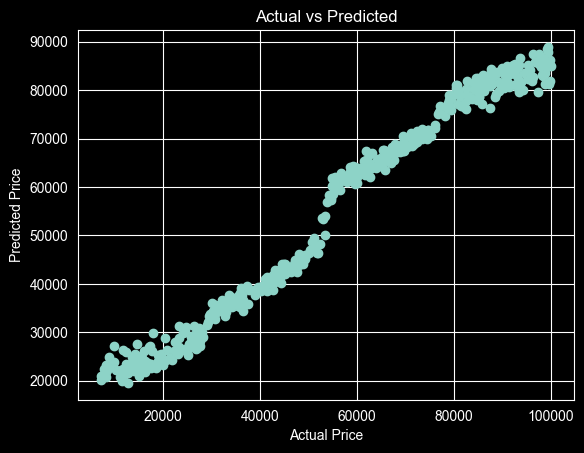

In [177]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [178]:
df_test = pd.read_csv('test.csv')

In [179]:
df_test = df_test.drop('id',axis=1)

In [180]:
df_test.columns = X.columns

In [181]:
final_predictions = pipe.predict(df_test)

In [182]:
df_test['PredictedPrice']= final_predictions

In [183]:
df_test['PredictedPrice']

0      80340.345347
1      84332.050595
2      63765.209020
3      81904.108682
4      42869.233241
           ...     
995    54353.028153
996    46571.518898
997    33833.612698
998    65445.795024
999    70264.644945
Name: PredictedPrice, Length: 1000, dtype: float64

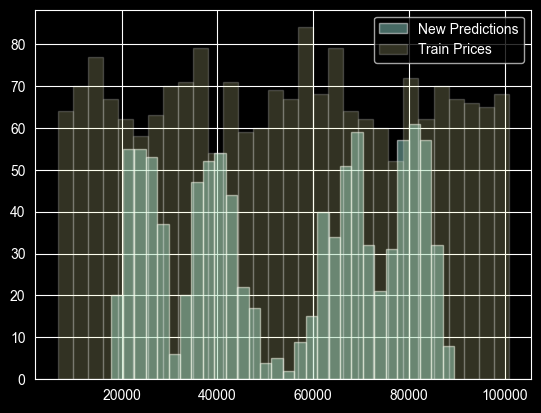

In [185]:
import matplotlib.pyplot as plt

plt.hist(df_test['PredictedPrice'], bins=30, alpha=0.5, label="New Predictions")
plt.hist(df['PriceRange'], bins=30, alpha=0.2, label="Train Prices")
plt.legend()
plt.show()